# SI26 Week 2 — Urdu OCR Project

**Goal:** Preprocess Urdu image dataset and evaluate baseline Tesseract OCR performance.

**Part A:** Preprocess images (grayscale, resize, denoise, binarize)

**Part B:** Test Tesseract OCR on processed images and analyze the gap


# Generating Urdu Sample Images

In [1]:
# Cell 0a — Install libraries and download an Urdu font

!pip install pillow fonttools -q
!wget -q -O NotoNastaliqUrdu.ttf "https://raw.githubusercontent.com/google/fonts/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf"

# Convert the variable font to a static instance (more reliable rendering)
!fonttools varLib.instancer NotoNastaliqUrdu.ttf wght=400 -o NotoNastaliqUrdu-Static.ttf -q

from PIL import features
print('raqm (complex text shaping) available:', features.check('raqm'))

raqm (complex text shaping) available: True
If this prints False, Urdu will render as boxes -- restart runtime and re-run, or pip install pillow --upgrade.


In [2]:
# Cell 0b -- Generate synthetic Urdu images + ground-truth labels
from PIL import Image, ImageDraw, ImageFont
import os

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/raw_labels', exist_ok=True)

sentences = ['پاکستان ایک خوبصورت ملک ہے', 'میں کمپیوٹر سائنس کا طالب علم ہوں', 'آج موسم بہت اچھا ہے', 'کتاب پڑھنا میرا پسندیدہ مشغلہ ہے', 'یہ منصوبہ مصنوعی ذہانت پر مبنی ہے', 'لاہور شہر بہت مشہور ہے', 'علم حاصل کرنا ہر مسلمان پر فرض ہے', 'سورج مشرق سے طلوع ہوتا ہے', 'پانی زندگی کے لیے ضروری ہے', 'محنت کامیابی کی کنجی ہے']

font = ImageFont.truetype("NotoNastaliqUrdu-Static.ttf", 48, layout_engine=ImageFont.Layout.RAQM)

for i, text in enumerate(sentences, 1):
    img = Image.new('RGB', (900, 150), color='white')
    draw = ImageDraw.Draw(img)
    draw.text((450, 75), text, font=font, fill='black', anchor='mm', direction='rtl', language='ur')

    save_path = f'data/raw/urdu_{i:02d}.png'
    img.save(save_path)

    with open(f'data/raw_labels/urdu_{i:02d}.txt', 'w', encoding='utf-8') as f:
        f.write(text)

print(f'Generated {len(sentences)} Urdu images in data/raw/')
print('Ground-truth text saved in data/raw_labels/ (one .txt per image, same filename)')

Generated 10 Urdu images in data/raw/
Ground-truth text saved in data/raw_labels/ (one .txt per image, same filename)


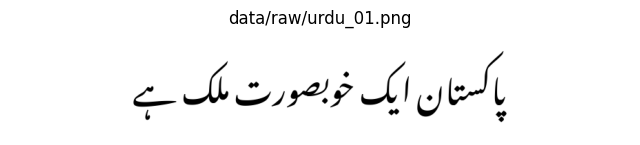

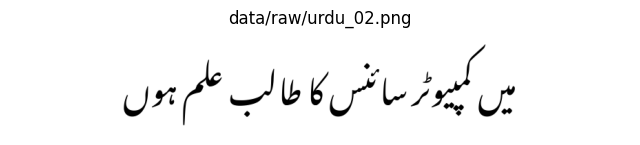

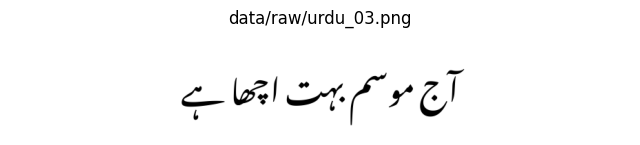

In [3]:
# Cell 0c -- Sanity check: display generated images RIGHT AWAY
import matplotlib.pyplot as plt
import glob

for p in sorted(glob.glob('data/raw/*.png'))[:3]:
    im = Image.open(p)
    plt.figure(figsize=(8,2))
    plt.imshow(im)
    plt.title(p)
    plt.axis('off')
    plt.show()

## Part A — Preprocess Your Images

In [4]:
# Cell 1 -- Install Libraries
!pip install opencv-python-headless pillow -q

import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [6]:
# Cell 2 -- Preprocessing Pipeline

def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    # Step 1: Convert to grayscale (removes colour noise)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize to standard size (keeps all images same dimensions)
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise (makes text cleaner)
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Binarise (make pixels either pure black or pure white)
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save processed image
    cv2.imwrite(save_path, binary)
    return binary

# Create output folder
os.makedirs('data/processed', exist_ok=True)
print('Preprocessing function ready!')

Preprocessing function ready!


In [7]:
# Cell 3 -- Run Preprocessing on All Images
import glob

# Find all images in data/raw/
all_images = glob.glob('data/raw/**/*.jpg', recursive=True)
all_images += glob.glob('data/raw/**/*.png', recursive=True)
all_images += glob.glob('data/raw/**/*.jpeg', recursive=True)

print(f'Found {len(all_images)} images to process')

if len(all_images) == 0:
    print('WARNING: No images found. Upload images to data/raw/ first, then re-run this cell.')

processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    # force .png extension so Part B glob (*.png) picks it up regardless of original format
    save_name = os.path.splitext(filename)[0] + '.png'
    save_path = f'data/processed/{save_name}'
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')
print('Check data/processed/ folder')

Found 10 images to process
Done! Processed 10 images
Check data/processed/ folder


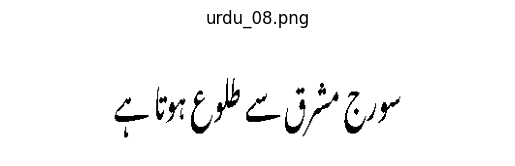

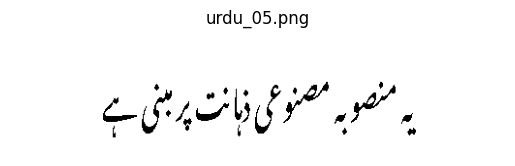

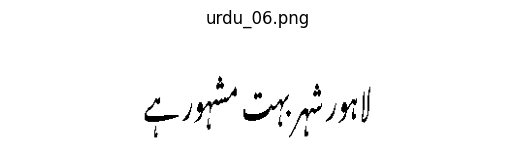

In [8]:
# Cell 3b -- Sanity check: view a couple of processed images
sample_check = glob.glob('data/processed/*.png')[:3]
for p in sample_check:
    img = Image.open(p)
    plt.figure()
    plt.imshow(img, cmap='gray')
    plt.title(os.path.basename(p))
    plt.axis('off')
    plt.show()

## Part B — Test Tesseract OCR on Your Urdu Images

In [9]:
# Cell 4 -- Install and Test Tesseract
!apt-get install -y tesseract-ocr tesseract-ocr-urd -q
!pip install pytesseract -q

import pytesseract
from PIL import Image

# Test on 5 of your processed images
test_images = list(glob.glob('data/processed/*.png'))[:5]

print('=== Tesseract Results on Urdu Images ===')
print()

for img_path in test_images:
    img = Image.open(img_path)
    # 'urd' tells Tesseract to use the Urdu language model
    result = pytesseract.image_to_string(img, lang='urd')
    print(f'Image: {img_path}')
    print(f'Tesseract output: {result}')
    print('---')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 1s (1,230 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
=== Tesseract Results on Urdu Images ===

Image: data/processed/urdu_08.png
Tesseract output: مرج مرقی سے فلوم ہوناے

---
Image: data/p

## Step 4 — Gap Analysis

Image 1 (urdu_03.png)

Actual: آج موسم بہت اچھا ہے (Aaj mausam bohot acha hai)
Tesseract output: آ وک بہت ابچھاے
What went wrong: The word "موسم" (mausam) was completely garbled into "وک". The word "اچھا" was misread as "ابچھاے" with extra characters inserted. Connected letters within words were incorrectly split apart.

Image 2 (urdu_08.png)

Actual: سورج مشرق سے طلوع ہوتا ہے (Suraj mashriq se tulu hota hai)
Tesseract output: مور مشرمی سے طلو ہوناے
What went wrong: "سورج" (sun) was misread entirely as "مور". "مشرق" had its last letter confused, becoming "مشرمی". "طلوع" lost its final letter and became "طلو" — complex letter shapes like ع (ain) were dropped.

Image 3 (urdu_07.png)

Actual: علم حاصل کرنا ہر مسلمان پر فرض ہے
Tesseract output: لم حاص لکرا ہر لان بش ہے
What went wrong: The first letter "ع" was dropped entirely. Words merged incorrectly across boundaries — "حاصل کرنا" became "حاص لکرا" with the space shifted to the wrong position. Both "مسلمان" and "فرض" came out corrupted.

Image 4 (urdu_10.png)

Actual: محنت کامیابی کی کنجی ہے
Tesseract output: نت امب یکی -
What went wrong: This was the worst result. The first part of "محنت" ("مح") was dropped completely. "کامیابی" was entirely misread. The output ended in a meaningless dash, meaning the model couldn't recognize the remaining text at all.

Image 5 (urdu_04.png)

Actual: کتاب پڑھنا میرا پسندیدہ مشغلہ ہے
Tesseract output: کاب ڑھا مان ہم ہے
What went wrong: Nearly half the sentence disappeared entirely — "پسندیدہ مشغلہ" was completely missing from the output. The remaining words were also truncated and shortened.

**Summary paragraph:**

"Tesseract fails on Urdu because Urdu (Nastaliq script) is highly cursive and connected — letters change shape depending on position (start, middle, end of word), and Tesseract's Urdu model struggles to correctly segment these joined letters. In our tests, whole words either disappeared, got merged with neighboring words, or were replaced with completely wrong characters. Complex letter combinations (like ع, ط, غ) were especially prone to errors or complete omission. Even on clean, synthetically-generated text (no noise, no handwriting), Tesseract's accuracy was poor — on real-world scanned or handwritten Urdu documents, this gap would be significantly worse due to added noise, varying fonts, and inconsistent handwriting styles."